## Unsupervised learning: Oja's rule

In the first part of this exercise we will reproduce the Figures in Chapter 39 of the MacKay book.

$x$ is an $p \times N$ matrix containing all the N-dimensional input vectors for each of the p patterns. We pick $N=2$ and set x[0]=-1, so that w[0] is the threshold, and w[1] and w[2] are the weights.

$t$ is a vector of length p containing the targets for each training pattern, each target $\in$ {0,1}

We can choose two options: linearly separable patterns, or nonseparable patterns

In [7]:
import numpy as np
from matplotlib import pyplot as plt
np.random.seed(1)

## Generate training set

Phi 0.7853981633974483


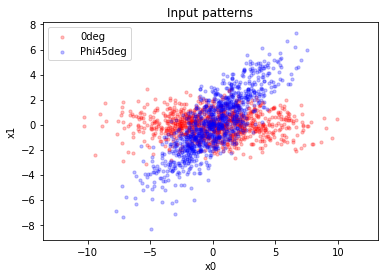

In [12]:
# multivariate gaussian patterns


size=10
fig,ax=plt.subplots()
ax.scatter(xinit[:,0],xinit[:,1],s=size,color='red',alpha=0.25,label='0deg')
ax.scatter(x[:,0],x[:,1],s=size,color='blue',alpha=0.25,label='Phi{:}deg'.format(angle))
ax.set_xlabel('x0'); ax.set_ylabel('x1'); ax.set_title('Input patterns');
ax.axis('equal')
ax.legend()

## Principal Component Analysis

PCs (column vectors in V):
[[-0.70987474  0.70432795]
 [-0.70432795 -0.70987474]]
PC eigenvalues:
[10.31597961  1.00207979]
percentage of variance explained:
[91.14618725  8.85381275]


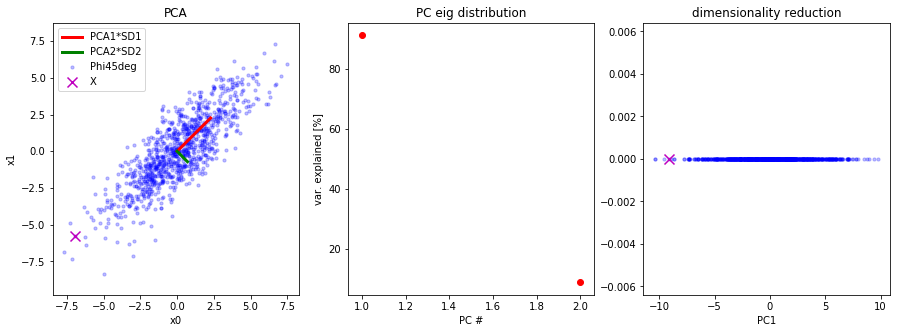

In [13]:
def cov(data):
    # for mean centered data
    return np.dot(data.T,data)/data.shape[0]

def pca(data,pc_count=None):



score,E,V=pca(x)
print('PCs (column vectors in V):'); print(V)
print('PC eigenvalues:'); print(E)
print('percentage of variance explained:'); print(100*E/sum(E))
if (V[0,0]<0) & (V[1,0]<0):
    V[:,0]=-V[:,0] # set PC1 it in the 1st quadrant
    score[:,0]=-score[:,0]
    
fig,ax=plt.subplots(1,3,figsize=(15,5))

# plot PCA eigenvectors
ax[0].scatter(x[:,0],x[:,1],s=size,color='blue',alpha=0.25,label='Phi{:}deg'.format(angle))
ax[0].scatter(x[-1,0],x[-1,1],s=100,color='m',marker='x',label='X')
ax[0].plot([0,np.sqrt(E[0])*V[0,0]],[0,np.sqrt(E[0])*V[1,0]],color='red',linewidth=3,label='PCA1*SD1')
ax[0].plot([0,np.sqrt(E[1])*V[0,1]],[0,np.sqrt(E[1])*V[1,1]],color='green',linewidth=3,label='PCA2*SD2')
ax[0].set_xlabel('x0'); ax[0].set_ylabel('x1'); ax[0].set_title('PCA');
ax[0].axis('equal')
ax[0].legend()

# distribution of eigenvalues
percE=100*E/sum(E)
indPC=np.arange(len(percE))+1
ax[1].scatter(indPC,percE,c='r')
ax[1].set_xlabel('PC #'); ax[1].set_ylabel('var. explained [%]'); ax[1].set_title('PC eig distribution');

# dimensionality reduction on PC1
ax[2].scatter(score[:,0],np.zeros((p,1)),s=10,color='blue',alpha=0.25)
ax[2].scatter(score[-1,0],0,s=100,color='m',marker='x',label='X')
ax[2].set_xlabel('PC1'); ax[2].set_ylabel(''); ax[2].set_title('dimensionality reduction');


## Activity rule 
Activity: 
$$
{\cal O}=f(h)=\sum_{i=1}^N w_i x_i
$$

## Online training using Oja's learning rule
$$
\Delta w_i=\eta {\cal O}\left(x_i^\mu-\alpha {\cal O} w_i\right)
$$

initial weights [ 6.123234e-17 -1.000000e+00]


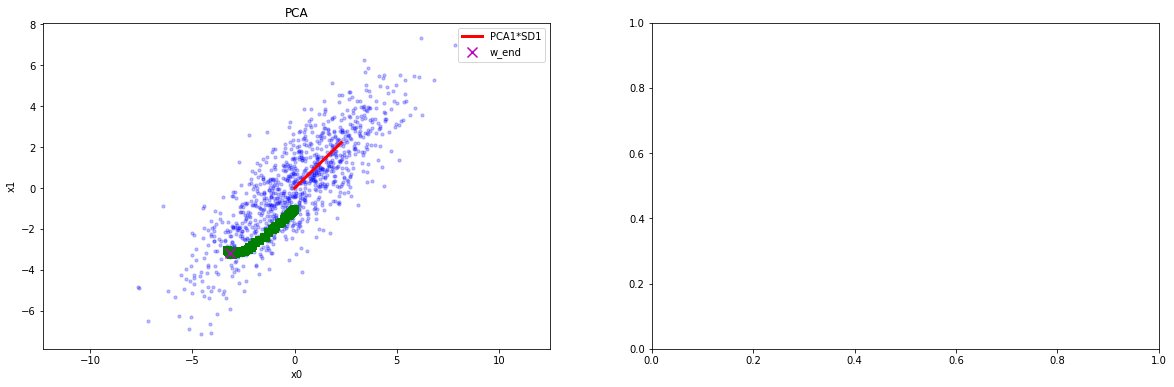

In [5]:
Tfold=1 # number of repeats over the whole batch
stepPlot=10 # snapshot

eta=0.001 # learning rate
alpha=0.05 # weight decay

# initial weights

print('initial weights %s' % w)


            
# plot training        
wplot=np.array(wplot)
fig,ax=plt.subplots(1,1,figsize=(20,6))
# learning steps
xplot=stepPlot*(np.arange(len(wplot)))
ax[0].scatter(x[:,0],x[:,1],s=size,color='blue',alpha=0.25)#,label='Phi{:}deg'.format(angle))
# ax[0].scatter(x[-1,0],x[-1,1],s=100,color='m',marker='x',label='X')
ax[0].plot([0,np.sqrt(E[0])*V[0,0]],[0,np.sqrt(E[0])*V[1,0]],color='red',linewidth=3,label='PCA1*SD1')
# ax[0].plot([0,np.sqrt(E[1])*V[0,1]],[0,np.sqrt(E[1])*V[1,1]],color='green',linewidth=3,label='PCA2*SD2')
ax[0].scatter(wplot[:,0],wplot[:,1],s=50,marker='s',c='g')
ax[0].scatter(wplot[-1,0],wplot[-1,1],s=100,color='m',marker='x',label='w_end')



ax[0].set_xlabel('x0'); ax[0].set_ylabel('x1'); ax[0].set_title('PCA');
ax[0].axis('equal')
ax[0].legend()


### Optional assignments: (5+5+5 extra points)

Question 1: Train the network using p=10.000 circular data points generated with covariance matrix C=[[1,0],[0,1]]. Train the network several times starting from different random initial conditions for the weights. What happens to the weights? Train the network for a longer time: what do the weights converge to? Propose an explanation for what you found.



Question 2: Train the network using p=1000 data points generated with covariance matrix C=[[10,0],[0,1]] and mean mu=[10,10]. What happens to the weights? Do the weights still represent the 1st PC, or something else? Why?



Question 3: Train the network using the unsupervised learning rule derived in the previous assignment:
$$
\Delta w_i=\eta[(Cw)_i-\alpha w_i(w^Tw)]
$$
What is the difference between the weights obtained from Oja's rule and the weights obtained from this new rule?